# R2-#4/adduct-stratification: per-adduct performance vs. training-set representation

Reviewer comment: "The current model evaluation aggregates overall error metrics across all adduct types. ... Averaging global metrics severely conceals potential predictive collapses occurring within these underrepresented minority adduct types. The study requires a stratified performance table detailing mean relative errors across each adduct type ... It would be even better if the relationship between predictive performance and the number of adducts in the training set for each additive ion type could be further analyzed."

Two things below: (1) a per-adduct stratified table (MAE/MRE/MDRE per adduct, not just the aggregate over the whole test set), and (2) whether per-adduct error is related to how many training examples that adduct had -- i.e. is degraded performance on rare adducts explained by data scarcity rather than an unexplained model weakness.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
})

train_df = pd.read_csv("../../train_data.csv")
preds_df = pd.read_csv("../../testset_predictions_ohe_adductmass.csv")

train_counts = train_df["adduct"].value_counts().rename("N_train")

## Stratified per-adduct performance table

In [8]:
def compute_adduct_metrics(df):
    rows = []
    for adduct, group in df.groupby("Adduct"):
        y_true = group["CCS_True"].to_numpy(dtype=float)
        y_pred = group["CCS_Pred"].to_numpy(dtype=float)
        abs_error = np.abs(y_true - y_pred)
        rel_error = abs_error / y_true * 100
        rows.append({
            "Adduct": adduct,
            "N_test": len(group),
            "MAE": abs_error.mean(),
            "MDAE": np.median(abs_error),
            "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
            "MRE_%": rel_error.mean(),
            "MDRE_%": np.median(rel_error),
        })
    return pd.DataFrame(rows)


table = compute_adduct_metrics(preds_df).merge(train_counts, left_on="Adduct", right_index=True, how="left")
table["N_train"] = table["N_train"].fillna(0).astype(int)
table = table.sort_values("N_train", ascending=False).reset_index(drop=True)

zero_train = table[table["N_train"] == 0]
if len(zero_train):
    print(f"{len(zero_train)} adduct(s) in the test set with ZERO training examples (most extreme 'unfamiliar adduct' case):")
    display(zero_train.round(3))

display(table.round(3))

1 adduct(s) in the test set with ZERO training examples (most extreme 'unfamiliar adduct' case):


,Adduct,N_test,MAE,MDAE,RMSE,MRE_%,MDRE_%,N_train
36,[M]-,1,10.172,10.172,10.172,5.334,5.334,0


,Adduct,N_test,MAE,MDAE,RMSE,MRE_%,MDRE_%,N_train
0,[M+H]+,5268,2.809,2.051,4.020,1.494,1.101,22098
1,[M-H]-,3283,3.812,2.642,5.455,1.986,1.406,14148
2,[M+Na]+,3184,3.639,2.626,5.279,1.847,1.338,13284
3,[M+H-H2O]+,283,2.996,1.917,4.856,1.744,1.180,976
4,[M+K]+,282,4.769,3.543,6.628,2.623,1.833,943
5,[M+NH4]+,145,3.526,2.983,4.423,1.204,1.109,538
6,[M+HCOO]-,99,2.502,1.960,3.637,1.250,0.838,392
7,[M]+,66,1.883,1.147,2.881,1.063,0.713,245
8,[M+Na-2H]-,40,3.808,2.618,5.604,2.140,1.494,134
9,[M+Cl]-,39,2.165,1.716,2.884,1.041,0.731,132


## Performance vs. training-set representation

Plotted on a log-x scale since adduct training counts span roughly four orders of magnitude (single digits up to 22,000+ for `[M+H]+`). Adducts with zero training examples can't be placed on a log axis or included in the correlation, so they're annotated separately rather than dropped from the discussion.

Spearman correlation (log10 N_train vs. MDRE%), n=36 adducts: rho=-0.3082, p=0.0674


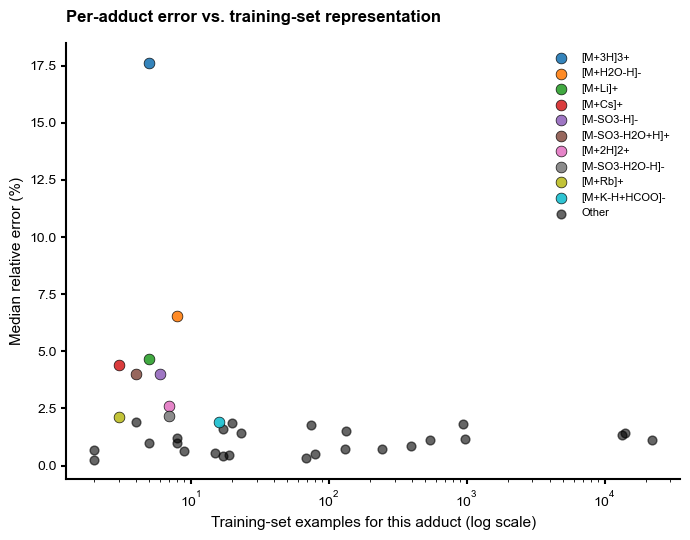

In [10]:
corr_subset = table[table["N_train"] > 0]
rho, p = spearmanr(np.log10(corr_subset["N_train"]), corr_subset["MDRE_%"])
print(f"Spearman correlation (log10 N_train vs. MDRE%), n={len(corr_subset)} adducts: rho={rho:.4f}, p={p:.4f}")

top10 = corr_subset.nlargest(10, "MDRE_%")
top10_adducts = top10["Adduct"].tolist()
is_top10 = corr_subset["Adduct"].isin(top10_adducts)

cmap = plt.get_cmap("tab10")
adduct_colors = {adduct: cmap(i) for i, adduct in enumerate(top10_adducts)}

fig, ax = plt.subplots(figsize=(7, 5.5))

for _, row in top10.iterrows():
    ax.scatter(row["N_train"], row["MDRE_%"], s=60, alpha=0.9,
               color=adduct_colors[row["Adduct"]], edgecolors="black", linewidth=0.5,
               zorder=3, label=row["Adduct"])

other = corr_subset[~is_top10]
ax.scatter(other["N_train"], other["MDRE_%"], s=40, alpha=0.6, color="black", zorder=2, label="Other")

ax.set_xscale("log")
ax.set_xlabel("Training-set examples for this adduct (log scale)")
ax.set_ylabel("Median relative error (%)")
ax.set_title("Per-adduct error vs. training-set representation", loc="left", fontweight="bold", pad=15)
ax.legend(frameon=False, fontsize=8, loc="best")

plt.tight_layout()
plt.show()